**RF-SVR model**

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from itertools import product

In [2]:
df = pd.read_csv('../data/df_with_2regimes.csv')

# lag 1,2 andd 3 of realized variance
df['rv_lag1'] = df['realized_variance'].shift(1)
df['rv_lag2'] = df['realized_variance'].shift(2)
df['rv_lag3'] = df['realized_variance'].shift(3)

# rolling mean of realized volatility over the past 30 days
df['rv_rolling_mean_30'] = df['realized_variance'].rolling(window=30).mean() 

# take log of realized variance
df['log_realized_variance'] = np.log(df['realized_variance'])

# drop rows with NaN values (due to lag and rolling mean)
df = df.dropna().reset_index(drop=True)
df.head(30)
df.info()
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489 entries, 0 to 3488
Data columns (total 42 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        3489 non-null   object 
 1   log_return                                  3489 non-null   float64
 2   realized_variance                           3489 non-null   float64
 3   realized_volatility                         3489 non-null   float64
 4   gtrend_pct_change                           3489 non-null   float64
 5   blockchain_diff_log_n_transactions          3489 non-null   float64
 6   blockchain_diff_log_transaction_fee_usd     3489 non-null   float64
 7   blockchain_diff_log_n_unique_addresses      3489 non-null   float64
 8   blockchain_diff_log_transaction_volume_usd  3489 non-null   float64
 9   log_volume                                  3489 non-null   float64
 10  target      

In [3]:
rf_features = ["log_return", "gtrend_pct_change",
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "log_volume",
    "gold_close_ret",
    "silver_close_ret",
    "brent_close_ret",
    "dji_close_ret",
    "spx_close_ret",
    "rut_close_ret",
    "nasdaq_close_ret",
    "usdcny_close_ret",
    "usdeur_close_ret",
    "gold_volume_chg",
    "silver_volume_chg",
    "brent_volume_chg",
    "dji_volume_chg",
    "spx_volume_chg",
    "rut_volume_chg",
    "nasdaq_volume_chg",
    "vix_close_chg",
    "hash-rate_chg",
    "difficulty_chg",
    "median-confirmation-time_chg",
    "blockchain_log_mempool_count_chg"
    ]

svr_features = ["rv_lag1", "rv_lag2", "rv_lag3", "rv_rolling_mean_30"]

target_col = "regime_id"

In [4]:
# function to create lags
def add_lagged_features(df, feature_cols, lags):
    for lag in lags:
        for col in feature_cols:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)
    return df

In [5]:
df = add_lagged_features(df, rf_features, lags=[1, 2, 3])

In [6]:
# start from 2017-07-13
df = df[df['date'] >= '2017-07-13'].reset_index(drop=True)
df.head()
df.tail()

,date,log_return,realized_variance,realized_volatility,gtrend_pct_change,blockchain_diff_log_n_transactions,blockchain_diff_log_transaction_fee_usd,blockchain_diff_log_n_unique_addresses,blockchain_diff_log_transaction_volume_usd,log_volume,...,brent_volume_chg_lag3,dji_volume_chg_lag3,spx_volume_chg_lag3,rut_volume_chg_lag3,nasdaq_volume_chg_lag3,vix_close_chg_lag3,hash-rate_chg_lag3,difficulty_chg_lag3,median-confirmation-time_chg_lag3,blockchain_log_mempool_count_chg_lag3
3120,2026-01-27,0.009776,0.000485,0.022018,-0.061538,-0.104979,-0.046198,0.021370,-0.235868,8.775873,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.356675,0.0,0.238187,0.022814
3121,2026-01-28,0.000510,0.000319,0.017847,-0.065574,-0.075153,0.240570,0.021306,0.359595,8.800436,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.097164,0.0,0.199412,-0.020043
3122,2026-01-29,-0.053552,0.001190,0.034490,0.333333,0.243422,-0.024924,0.071430,0.118684,9.606559,...,-0.276621,-0.014551,0.019537,0.019537,-0.092033,0.003722,0.138150,0.0,-0.177441,-0.008895
3123,2026-01-30,-0.004770,0.000855,0.029246,0.171053,-0.118552,0.068726,0.107636,0.416170,9.631273,...,0.285752,0.161072,0.070646,0.070646,0.067090,0.012308,-0.016261,0.0,-0.185390,-0.016174
3124,2026-01-31,-0.067155,0.000998,0.031598,0.123596,0.062615,-0.051867,-0.096210,-0.546907,9.606164,...,-0.376594,-0.125147,0.032468,0.032468,0.015519,0.000000,-0.103541,0.0,0.263815,0.073174


In [7]:
print(df.isna().sum().to_string())

date                                               0
log_return                                         0
realized_variance                                  0
realized_volatility                                0
gtrend_pct_change                                  0
blockchain_diff_log_n_transactions                 0
blockchain_diff_log_transaction_fee_usd            0
blockchain_diff_log_n_unique_addresses             0
blockchain_diff_log_transaction_volume_usd         0
log_volume                                         0
target                                             0
gold_close_ret                                     0
silver_close_ret                                   0
brent_close_ret                                    0
dji_close_ret                                      0
spx_close_ret                                      0
rut_close_ret                                      0
nasdaq_close_ret                                   0
usdcny_close_ret                              

In [8]:
rf_feature_cols = []
for col in rf_features:
    rf_feature_cols.append(col)
    rf_feature_cols.append(f"{col}_lag1")
    rf_feature_cols.append(f"{col}_lag2")
    rf_feature_cols.append(f"{col}_lag3")

print(f"Total RF features: {len(rf_feature_cols)}")

Total RF features: 112


In [9]:
# Split: 60% train, 25% eval, 15% test
n = len(df)
train_size = int(n * 0.60)
eval_size = int(n * 0.25)

train_df = df.iloc[:train_size].copy()
eval_df = df.iloc[train_size:train_size+eval_size].copy()
test_df = df.iloc[train_size+eval_size:].copy()

print(f"\nTrain: {len(train_df)} rows")
print(f"Eval: {len(eval_df)} rows")
print(f"Test: {len(test_df)} rows")


Train: 1875 rows
Eval: 781 rows
Test: 469 rows


In [10]:
def create_rolling_scaled_sequences_range_rf(
    df, feature_cols, target_col, lookback, scale_window, start_idx, end_idx, date_col=None
):
    X, y, dates = [], [], []
    
    first_valid_idx = max(start_idx, lookback, scale_window)
    
    for t in range(first_valid_idx, end_idx - 1):
        hist_window = df[feature_cols].iloc[t - scale_window + 1:t + 1]
        lookback_window = df[feature_cols].iloc[t - lookback + 1:t + 1]
        
        target = df[target_col].iloc[t + 1]
        
        if hist_window.isnull().any().any():
            continue
        if lookback_window.isnull().any().any():
            continue
        if pd.isna(target):
            continue
        
        scaler = StandardScaler()
        scaler.fit(hist_window)
        
        scaled_window = scaler.transform(lookback_window)
        flattened_features = scaled_window.flatten()
        
        X.append(flattened_features)
        y.append(target)
        
        if date_col is not None:
            dates.append(df[date_col].iloc[t + 1])
        else:
            dates.append(t + 1)
    
    return np.array(X), np.array(y), dates

In [11]:
def get_rf_features_for_prediction(df_hist, feature_cols, lookback, scale_window=730):
    scaler_hist = df_hist[feature_cols].iloc[-min(scale_window, len(df_hist)):].copy()
    
    scaler = StandardScaler()
    scaler.fit(scaler_hist)
    
    lookback_window = df_hist[feature_cols].iloc[-lookback:].copy()
    
    scaled_window = scaler.transform(lookback_window)
    flattened_features = scaled_window.flatten()
    
    return flattened_features, scaler

In [12]:
def rolling_regime_forecast_rf(
    df_full,
    rf_model,
    feature_cols,
    lookback,
    start_idx,
    end_idx,
    scale_window=730,
    date_col="date",
    target_col="regime_id"
):
    results = []
    
    for t in range(start_idx - 1, end_idx - 1):
        df_hist = df_full.iloc[:t+1].copy()
        
        if len(df_hist) < lookback:
            continue
        
        try:
            features, _ = get_rf_features_for_prediction(
                df_hist,
                feature_cols=feature_cols,
                lookback=lookback,
                scale_window=scale_window
            )
        except Exception:
            continue
        
        X_input = features.reshape(1, -1)
        
        pred_regime = rf_model.predict(X_input)[0]
        pred_probs = rf_model.predict_proba(X_input)[0]
        
        results.append({
            "date": df_full.iloc[t][date_col],
            "pred_regime": int(pred_regime),
            "pred_prob_0": pred_probs[0],
            "pred_prob_1": pred_probs[1] if len(pred_probs) > 1 else 0.0
        })
    
    return pd.DataFrame(results)

In [13]:
def rolling_rf_svr_linear_eval(
    df_full,
    regime_forecast_df,
    start_idx,
    end_idx,
    x_feature_cols,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    C=1.0,
    epsilon=1e-4,
    min_obs=200,
    use_prob_1_only=True,
    kernel="linear"
):
    results = []
    
    df = df_full.copy()
    regime_df = regime_forecast_df.copy()
    
    merge_cols = [date_col, "pred_regime", "pred_prob_0", "pred_prob_1"]
    df = df.merge(regime_df[merge_cols], on=date_col, how="left")
    
    # target is next day's realized variance
    df["rv_lead1"] = df[realized_var_col].shift(-1)
    
    # row t stores regime forecast for t+1 made using info up to t
    df["prob1_for_next_day"] = df["pred_prob_1"]
    df["prob0_for_next_day"] = df["pred_prob_0"]
    df["regime_for_next_day"] = df["pred_regime"]
    
    prob_cols = ["prob1_for_next_day"] if use_prob_1_only else ["prob0_for_next_day", "prob1_for_next_day"]
    feature_cols = x_feature_cols + prob_cols
    
    for t in range(start_idx - 1, end_idx - 1):
        current_row = df.iloc[t]
        next_row = df.iloc[t + 1]
        
        current_date = current_row[date_col]
        next_date = next_row[date_col]
        
        # training ends at t-1, so row t is excluded
        window_df = df.iloc[max(0, t - rolling_window + 1): t].copy()
        
        needed_cols = feature_cols + ["rv_lead1"]
        train_df = window_df[needed_cols].dropna()
        
        if len(train_df) < min_obs:
            results.append({
                "date": next_date,
                "forecast_origin_date": current_date,
                "actual_var": next_row[realized_var_col],
                "pred_regime": current_row.get("regime_for_next_day", np.nan),
                "pred_prob_0": current_row.get("prob0_for_next_day", np.nan),
                "pred_prob_1": current_row.get("prob1_for_next_day", np.nan),
                "var_svr": np.nan
            })
            continue
        
        X_train = train_df[feature_cols].values
        y_train = train_df["rv_lead1"].values
        
        model = fit_svr_safe(
            X_train=X_train,
            y_train=y_train,
            kernel=kernel,
            C=C,
            epsilon=epsilon,
            min_obs=min_obs
        )
        
        x_t = current_row[feature_cols]
        
        if x_t.isna().any():
            pred = np.nan
        else:
            pred = one_step_svr_forecast(model, x_t.values)
        
        results.append({
            "date": next_date,
            "forecast_origin_date": current_date,
            "actual_var": next_row[realized_var_col],
            "pred_regime": current_row.get("regime_for_next_day", np.nan),
            "pred_prob_0": current_row.get("prob0_for_next_day", np.nan),
            "pred_prob_1": current_row.get("prob1_for_next_day", np.nan),
            "var_svr": pred
        })
    
    return pd.DataFrame(results)

In [14]:
def fit_svr_safe(X_train, y_train, C=1.0, kernel="linear", epsilon=1e-4, min_obs=250):
    if len(X_train) < min_obs:
        return None
    
    try:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel=kernel, C=C, epsilon=epsilon))
        ])
        model.fit(X_train, y_train)
        return model
    except Exception:
        return None

def one_step_svr_forecast(fitted_svr, x_next):
    if fitted_svr is None:
        return np.nan
    
    try:
        x_next = np.asarray(x_next).reshape(1, -1)
        pred = fitted_svr.predict(x_next)[0]
        return float(pred)
    except Exception:
        return np.nan

In [15]:
def train_random_forest(
    X_train,
    y_train,
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight=None,
    random_state=42
):
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight=class_weight,
        random_state=random_state,
        n_jobs=-1
    )
    
    rf_model.fit(X_train, y_train)
    
    return rf_model

In [16]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))

def qlike2(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)
    
    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)
    
    return test_qlike

In [17]:
# Define parameter grids
rf_grid = {
    "lookback": [30, 60],
    "n_estimators": [50, 100],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

rf_param_grid = []
for lb, n_est, max_depth, min_split in product(
    rf_grid["lookback"],
    rf_grid["n_estimators"],
    rf_grid["max_depth"],
    rf_grid["min_samples_split"]
):
    rf_param_grid.append({
        "lookback": lb,
        "n_estimators": n_est,
        "max_depth": max_depth,
        "min_samples_split": min_split
    })

# SVR grid (same as before)
svr_grid = {
    "kernel": ["linear"],
    "C": [0.1, 1.0, 10.0],
    "epsilon": [1e-4, 1e-3, 1e-2]
}

svr_param_grid = []
for kernel, C, epsilon in product(
    svr_grid["kernel"],
    svr_grid["C"],
    svr_grid["epsilon"]
):
    svr_param_grid.append({
        "kernel": kernel,
        "C": C,
        "epsilon": epsilon
    })

print(f"Total RF configs: {len(rf_param_grid)}")
print(f"Total SVR configs: {len(svr_param_grid)}")

Total RF configs: 24
Total SVR configs: 9


In [19]:
# Fixed SVR parameters for RF tuning
fixed_svr_params = {
    "kernel": "linear",
    "C": 1.0,
    "epsilon": 1e-4
}

stage2_window = 365
min_obs = 200

# Get eval indices
eval_start_idx = train_size
eval_end_idx = train_size + eval_size
evalA_size = eval_size // 2

evalA_start_idx = eval_start_idx
evalA_end_idx = evalA_start_idx + evalA_size
evalB_start_idx = evalA_end_idx
evalB_end_idx = eval_end_idx

print(f"Eval A: indices {evalA_start_idx} to {evalA_end_idx}")
print(f"Eval B: indices {evalB_start_idx} to {evalB_end_idx}")

# Tune RF on eval B
rf_results = []

for i, params in enumerate(rf_param_grid, 1):
    lb = params["lookback"]
    n_est = params["n_estimators"]
    max_depth = params["max_depth"]
    min_split = params["min_samples_split"]
    
    print(f"\n[{i}/{len(rf_param_grid)}] Testing RF: {params}")
    
    try:
        # Prepare training data from TRAIN set
        X_train_rf, y_train_rf, _ = create_rolling_scaled_sequences_range_rf(
            df=train_df,
            feature_cols=rf_feature_cols,
            target_col=target_col,
            lookback=lb,
            scale_window=365,
            start_idx=0,
            end_idx=len(train_df),
            date_col=None
        )
        
        # Train RF on TRAIN set
        rf_model = train_random_forest(
            X_train=X_train_rf,
            y_train=y_train_rf,
            n_estimators=n_est,
            max_depth=max_depth,
            min_samples_split=min_split,
            random_state=42
        )
        
        # Generate regime forecasts for eval A + eval B
        regime_start_idx = max(0, evalA_start_idx - stage2_window)
        
        evalAB_regime_roll = rolling_regime_forecast_rf(
            df_full=df,
            rf_model=rf_model,
            feature_cols=rf_feature_cols,
            lookback=lb,
            start_idx=regime_start_idx,
            end_idx=evalB_end_idx,
            scale_window=365,
            date_col="date"
        )
        
        # Evaluate SVR on eval B only
        evalB_stage2 = rolling_rf_svr_linear_eval(
            df_full=df,
            regime_forecast_df=evalAB_regime_roll,
            start_idx=evalB_start_idx,
            end_idx=evalB_end_idx,
            x_feature_cols=svr_features,
            realized_var_col="log_realized_variance",
            date_col="date",
            rolling_window=stage2_window,
            kernel=fixed_svr_params["kernel"],
            C=fixed_svr_params["C"],
            epsilon=fixed_svr_params["epsilon"],
            min_obs=min_obs,
            use_prob_1_only=True
        )
        
        evalB_rmse = rmse(evalB_stage2["actual_var"], evalB_stage2["var_svr"])
        evalB_qlike = qlike2(evalB_stage2["actual_var"], evalB_stage2["var_svr"])
        n_evalB_forecasts = evalB_stage2["var_svr"].notna().sum()
        
        rf_results.append({
            **params,
            "evalB_rmse": evalB_rmse,
            "evalB_qlike": evalB_qlike,
            "n_evalB_forecasts": n_evalB_forecasts
        })
        
    except Exception as e:
        print(f"Error for params {params}: {e}")
        rf_results.append({
            **params,
            "evalB_rmse": np.nan,
            "evalB_qlike": np.nan,
            "n_evalB_forecasts": 0,
            "error": str(e)
        })

rf_results_df = pd.DataFrame(rf_results).sort_values("evalB_qlike")
print("\nBest RF configurations:")
print(rf_results_df.head(10))

Eval A: indices 1875 to 2265
Eval B: indices 2265 to 2656

[1/24] Testing RF: {'lookback': 30, 'n_estimators': 50, 'max_depth': None, 'min_samples_split': 2}

[2/24] Testing RF: {'lookback': 30, 'n_estimators': 50, 'max_depth': None, 'min_samples_split': 5}

[3/24] Testing RF: {'lookback': 30, 'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 2}

[4/24] Testing RF: {'lookback': 30, 'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 5}

[5/24] Testing RF: {'lookback': 30, 'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 2}

[6/24] Testing RF: {'lookback': 30, 'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 5}

[7/24] Testing RF: {'lookback': 30, 'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2}

[8/24] Testing RF: {'lookback': 30, 'n_estimators': 100, 'max_depth': None, 'min_samples_split': 5}

[9/24] Testing RF: {'lookback': 30, 'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 2}

[10/24] Testing RF: {'lookback': 30, 'n_estimators'

In [21]:
# Get best RF parameters
best_rf_params = rf_results_df.iloc[0].to_dict()
print("\nBest RF parameters:")
print(best_rf_params)

best_lb = int(best_rf_params["lookback"])
best_n_est = int(best_rf_params["n_estimators"])
best_max_depth = int(best_rf_params["max_depth"])
best_min_split = int(best_rf_params["min_samples_split"])

# Train final RF on train set with best parameters
X_train_rf, y_train_rf, _ = create_rolling_scaled_sequences_range_rf(
    df=train_df,
    feature_cols=rf_feature_cols,
    target_col=target_col,
    lookback=best_lb,
    scale_window=365,
    start_idx=0,
    end_idx=len(train_df),
    date_col=None
)

best_rf_model = train_random_forest(
    X_train=X_train_rf,
    y_train=y_train_rf,
    n_estimators=best_n_est,
    max_depth=best_max_depth,
    min_samples_split=best_min_split,
    random_state=4211
)

print(f"\nFinal RF model trained with {len(X_train_rf)} samples")


Best RF parameters:
{'lookback': 30.0, 'n_estimators': 100.0, 'max_depth': 10.0, 'min_samples_split': 2.0, 'evalB_rmse': 0.9414420228680449, 'evalB_qlike': 0.00731747534004522, 'n_evalB_forecasts': 391.0}

Final RF model trained with 1509 samples


In [22]:
regime_start_idx = max(0, evalB_start_idx - stage2_window)

eval_regime_fixed = rolling_regime_forecast_rf(
    df_full=df,
    rf_model=best_rf_model,
    feature_cols=rf_feature_cols,
    lookback=best_lb,
    start_idx=regime_start_idx,
    end_idx=evalB_end_idx,
    scale_window=365,
    date_col="date"
)

# Tune SVR on eval B
svr_results = []

for i, params in enumerate(svr_param_grid, 1):
    kernel = params["kernel"]
    C = params["C"]
    epsilon = params["epsilon"]
    
    print(f"\n[{i}/{len(svr_param_grid)}] Testing SVR: {params}")
    
    try:
        evalB_svr = rolling_rf_svr_linear_eval(
            df_full=df,
            regime_forecast_df=eval_regime_fixed,
            start_idx=evalB_start_idx,
            end_idx=evalB_end_idx,
            x_feature_cols=svr_features,
            realized_var_col="log_realized_variance",
            date_col="date",
            rolling_window=365,
            C=C,
            epsilon=epsilon,
            min_obs=200,
            use_prob_1_only=True,
            kernel=kernel
        )
        
        evalB_rmse = rmse(evalB_svr["actual_var"], evalB_svr["var_svr"])
        evalB_qlike = qlike2(evalB_svr["actual_var"], evalB_svr["var_svr"])
        n_evalB_forecasts = evalB_svr["var_svr"].notna().sum()
        
        svr_results.append({
            **params,
            "evalB_rmse": evalB_rmse,
            "evalB_qlike": evalB_qlike,
            "n_evalB_forecasts": n_evalB_forecasts
        })
        
    except Exception as e:
        svr_results.append({
            **params,
            "evalB_rmse": np.nan,
            "evalB_qlike": np.nan,
            "n_evalB_forecasts": 0,
            "error": str(e)
        })

svr_results_df = pd.DataFrame(svr_results).sort_values("evalB_qlike")
print("\nBest SVR parameters:")
print(svr_results_df.head())


[1/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.0001}

[2/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.001}

[3/9] Testing SVR: {'kernel': 'linear', 'C': 0.1, 'epsilon': 0.01}

[4/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.0001}

[5/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.001}

[6/9] Testing SVR: {'kernel': 'linear', 'C': 1.0, 'epsilon': 0.01}

[7/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.0001}

[8/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.001}

[9/9] Testing SVR: {'kernel': 'linear', 'C': 10.0, 'epsilon': 0.01}

Best SVR parameters:
   kernel     C  epsilon  evalB_rmse  evalB_qlike  n_evalB_forecasts
0  linear   0.1   0.0001    0.944131     0.007365                391
1  linear   0.1   0.0010    0.944155     0.007365                391
2  linear   0.1   0.0100    0.944390     0.007369                391
4  linear   1.0   0.0010    0.945625     0.007388                391
6  linear

In [23]:
best_svr_params = svr_results_df.iloc[0].to_dict()
print("\nBest SVR parameters:")
print(best_svr_params)


Best SVR parameters:
{'kernel': 'linear', 'C': 0.1, 'epsilon': 0.0001, 'evalB_rmse': 0.9441309639843132, 'evalB_qlike': 0.0073645114701272945, 'n_evalB_forecasts': 391}


In [24]:
test_start_idx = train_size + eval_size
test_end_idx = len(df)

test_regime_start_idx = max(0, test_start_idx - 365)

test_regime_roll = rolling_regime_forecast_rf(
    df_full=df,
    rf_model=best_rf_model,
    feature_cols=rf_feature_cols,
    lookback=best_lb,
    start_idx=test_regime_start_idx,
    end_idx=test_end_idx,
    scale_window=365,
    date_col="date"
)

test_svr = rolling_rf_svr_linear_eval(
    df_full=df,
    regime_forecast_df=test_regime_roll,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    x_feature_cols=svr_features,
    realized_var_col="log_realized_variance",
    date_col="date",
    rolling_window=365,
    C=float(best_svr_params["C"]),
    epsilon=float(best_svr_params["epsilon"]),
    min_obs=200,
    use_prob_1_only=True,
    kernel=best_svr_params["kernel"]
)

test_rmse = rmse(test_svr["actual_var"], test_svr["var_svr"])
test_qlike = qlike2(test_svr["actual_var"], test_svr["var_svr"])

print("Final Test RMSE :", {test_rmse})
print("Final Test QLIKE:", {test_qlike})
print("Number of test forecasts:", test_svr['var_svr'].notna().sum())

Final Test RMSE : {np.float64(0.894216337381138)}
Final Test QLIKE: {np.float64(0.006355466440534026)}
Number of test forecasts: 469


In [25]:
test_svr.isna().sum()

date                    0
forecast_origin_date    0
actual_var              0
pred_regime             0
pred_prob_0             0
pred_prob_1             0
var_svr                 0
dtype: int64

In [26]:
test_svr.tail()

,date,forecast_origin_date,actual_var,pred_regime,pred_prob_0,pred_prob_1,var_svr
464,2026-01-27,2026-01-26,-7.631798,1.0,0.371039,0.628961,-7.996766
465,2026-01-28,2026-01-27,-8.051862,1.0,0.370837,0.629163,-8.011195
466,2026-01-29,2026-01-28,-6.734192,1.0,0.488808,0.511192,-8.523552
467,2026-01-30,2026-01-29,-7.064056,1.0,0.408353,0.591647,-8.135168
468,2026-01-31,2026-01-30,-6.909322,0.0,0.525913,0.474087,-8.577919


In [27]:
test_svr.head()

,date,forecast_origin_date,actual_var,pred_regime,pred_prob_0,pred_prob_1,var_svr
0,2024-10-20,2024-10-19,-9.314845,0.0,0.543889,0.456111,-8.285675
1,2024-10-21,2024-10-20,-7.873473,1.0,0.416431,0.583569,-7.819349
2,2024-10-22,2024-10-21,-8.046507,1.0,0.399432,0.600568,-7.782326
3,2024-10-23,2024-10-22,-8.161787,1.0,0.335599,0.664401,-7.536358
4,2024-10-24,2024-10-23,-7.997675,1.0,0.388644,0.611356,-7.715766


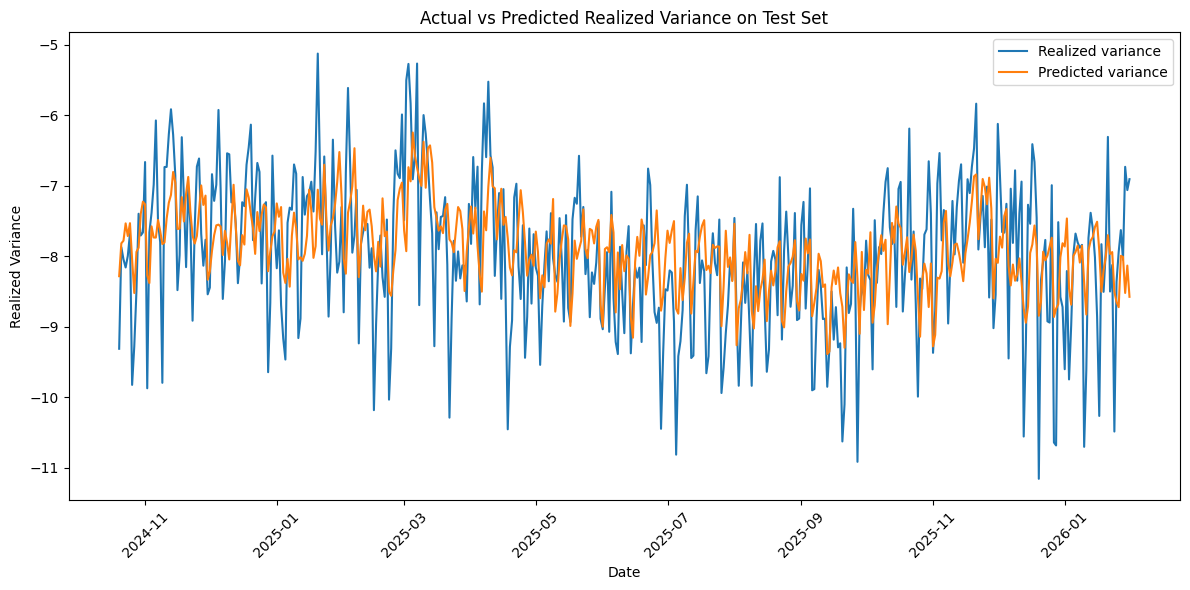

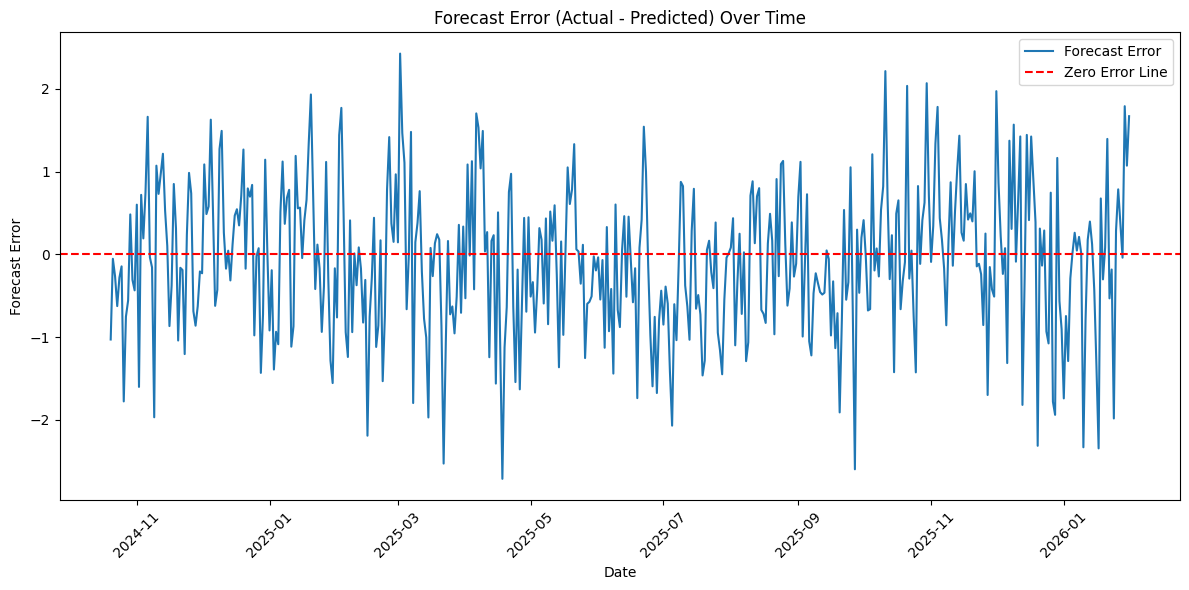

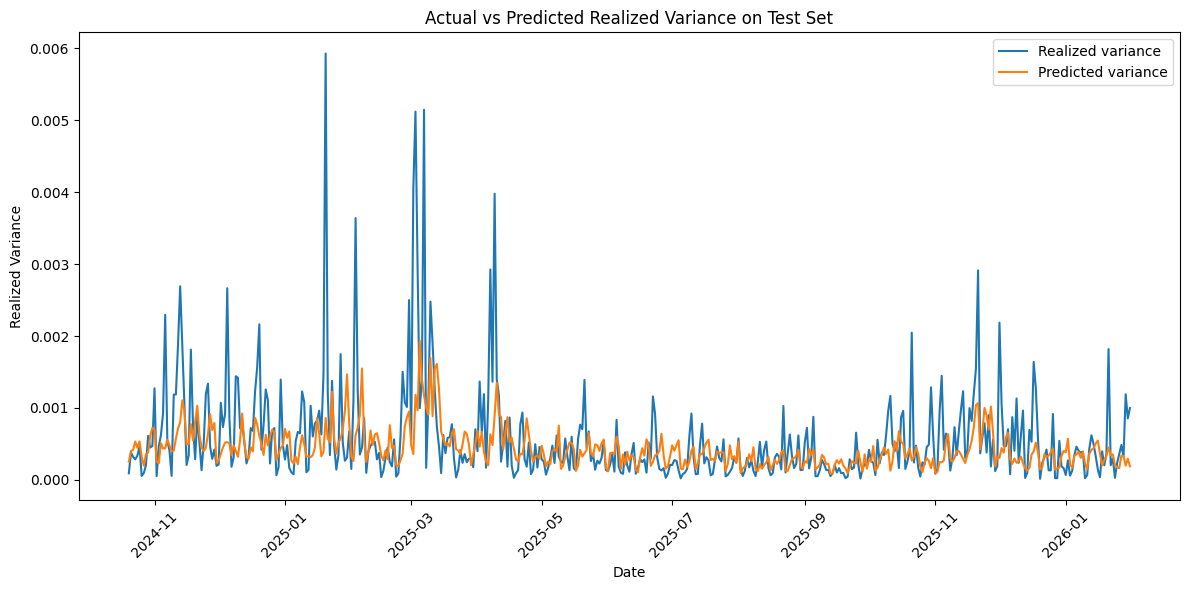

In [28]:
import matplotlib.pyplot as plt
test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["actual_var"], label="Realized variance")
plt.plot(test_svr["date"], test_svr["var_svr"], label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot errors over time
test_svr['date'] = pd.to_datetime(test_svr['date'])
test_svr['error'] = test_svr["actual_var"] - test_svr["var_svr"]
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], test_svr["error"], label="Forecast Error") 
plt.axhline(0, color='red', linestyle='--', label="Zero Error Line")
plt.title("Forecast Error (Actual - Predicted) Over Time")
plt.xlabel("Date")
plt.ylabel("Forecast Error")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


test_svr['date'] = pd.to_datetime(test_svr['date'])
plt.figure(figsize=(12,6))
plt.plot(test_svr["date"], np.exp(test_svr["actual_var"]), label="Realized variance")
plt.plot(test_svr["date"], np.exp(test_svr["var_svr"]), label="Predicted variance")
plt.title("Actual vs Predicted Realized Variance on Test Set")
plt.xlabel("Date")
plt.ylabel("Realized Variance")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()